In [1]:
# Import necessary libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import torch

# Set device to GPU if available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("GPU available: ", torch.cuda.is_available())

# Add parent directory to path to import functions
sys.path.append(os.path.abspath('..'))
from python.functions import *

GPU available:  True


In [2]:
# Download a test image
from PIL import Image

# Path to the image (to be replaced with actual path if needed)
image_path = '../Data/Balzac.jpg'

# Load the JPG image
img_pil = Image.open(image_path)

# Convert to grayscale and numpy array (0-255)
img_gray = img_pil.convert('L')  # 'L' mode = grayscale
img = np.array(img_gray, dtype=np.uint8)

print(f"Image shape: {img.shape}")
print(f"Value range: {img.min()} to {img.max()}")

Image shape: (593, 528)
Value range: 0 to 255


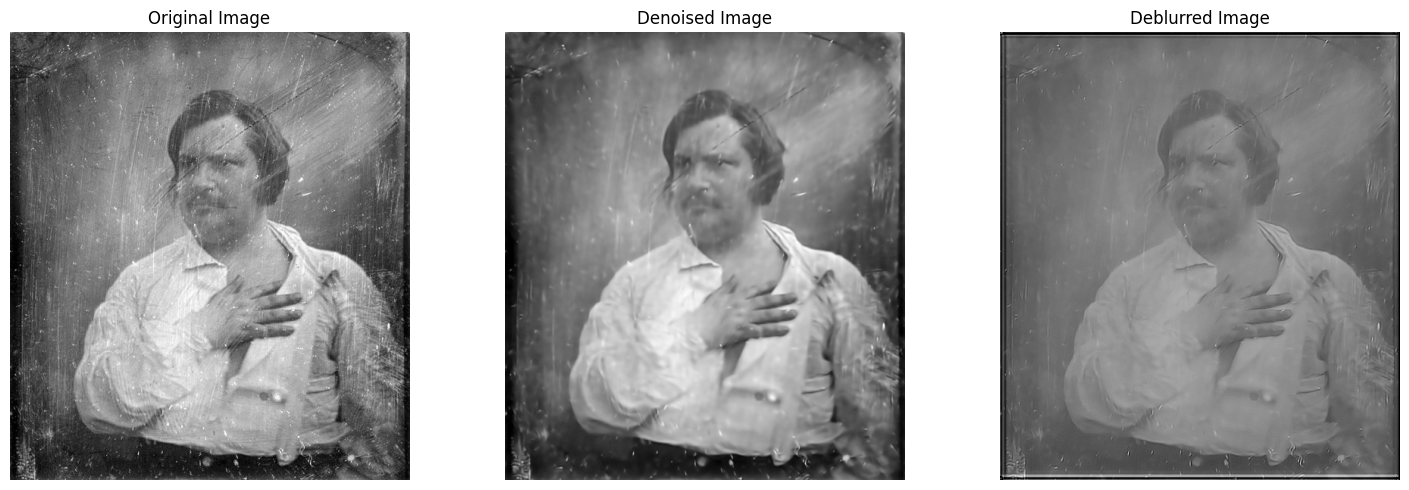

In [3]:
#%matplotlib qt

# Load the saved models
cnn_noise = torch.load('../CNN/dncnn_model.pth', weights_only=False)
cnn_blur = torch.load('../CNN/Blur_cnn_model.pth', weights_only=False)

# 1) Denoise the image using the trained model
cnn_noise.eval()  # Set model to evaluation mode
with torch.no_grad():  # Disable gradient computation for inference
    # Prepare noisy image as model input
    blurred = add_channel(img).unsqueeze(0).to(device)
    
    # Predict noise using DnCNN
    noise_pred = cnn_noise(blurred)
    
    # Reconstruct clean image: noisy - predicted_noise
    denoised = torch.clamp(blurred - noise_pred, 0, 1).cpu().squeeze()

# 2) Deblur the denoised image using the trained model
cnn_blur.eval()
with torch.no_grad():
    # Prepare denoised image as model input
    denoised_input = add_channel(denoised).unsqueeze(0).to(device)
    
    # Predict blur using Blur_cnn_model
    blur_pred = cnn_blur(denoised_input)
    
    # Reconstruct clean image: denoised - predicted_blur
    final_image = torch.clamp(denoised_input - blur_pred, 0, 1).cpu().squeeze()

# Visualize: Noisy → Denoised → Deblurred
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(denoised, cmap='gray')
plt.title("Denoised Image")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(final_image, cmap='gray')
plt.title("Deblurred Image")
plt.axis('off')

plt.tight_layout()
plt.show()